# Vision Stats: Season 2025 vs 2026 — Bronze I & Emerald I

Compares: `visionScorePerMinute`, `visionScore`, `controlWardsPlaced`, `stealthWardsPlaced`, `sightWardsBoughtInGame`, `visionWardsBoughtInGame`, `wardsPlaced`, `wardsKilled`

In [1]:
import json
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, normaltest, mannwhitneyu, ttest_ind, levene

sns.set_theme(style='whitegrid')

FEATURES = [
    'visionScorePerMinute',
    'visionScore',
    'controlWardsPlaced',
    'stealthWardsPlaced',
    'visionWardsBoughtInGame',
    'wardsPlaced',
    'wardsKilled',
]

## Load data

In [2]:
def extract_participant_features(filepath):
    """Return list of feature dicts — one per participant in the match."""
    with open(filepath, encoding='utf-8') as f:
        data = json.load(f)

    match_info = data.get('match_info', {})
    participants = data['match_data']['info']['participants']
    rows = []
    for p in participants:
        challenges = p.get('challenges', {})
        row = {
            # top-level fields
            'visionScore':            p.get('visionScore', np.nan),
            'sightWardsBoughtInGame': p.get('sightWardsBoughtInGame', np.nan),
            'visionWardsBoughtInGame':p.get('visionWardsBoughtInGame', np.nan),
            'wardsPlaced':            p.get('wardsPlaced', np.nan),
            'wardsKilled':            p.get('wardsKilled', np.nan),
            # challenge fields
            'visionScorePerMinute':   challenges.get('visionScorePerMinute', np.nan),
            'controlWardsPlaced':     challenges.get('controlWardsPlaced', np.nan),
            'stealthWardsPlaced':     challenges.get('stealthWardsPlaced', np.nan),
        }
        rows.append(row)
    return rows


def load_tier(season, tier):
    pattern = os.path.join('data', season, tier, '*.json')
    files = glob.glob(pattern)
    all_rows = []
    for fp in files:
        try:
            all_rows.extend(extract_participant_features(fp))
        except Exception as e:
            print(f'Skipping {fp}: {e}')
    df = pd.DataFrame(all_rows)
    df['season'] = season
    df['tier'] = tier
    return df


b25 = load_tier('season2025', 'bronze1')
b26 = load_tier('season2026', 'bronze1')
e25 = load_tier('season2025', 'emerald1')
e26 = load_tier('season2026', 'emerald1')

df_all = pd.concat([b25, b26, e25, e26], ignore_index=True)
df_all['group'] = df_all['season'] + '_' + df_all['tier']

print('Rows per group:')
print(df_all['group'].value_counts())

Rows per group:
group
season2026_emerald1    5330
season2026_bronze1     5300
season2025_emerald1    5000
season2025_bronze1     4230
Name: count, dtype: int64


In [3]:
b25.describe()

,visionScore,sightWardsBoughtInGame,visionWardsBoughtInGame,wardsPlaced,wardsKilled,visionScorePerMinute,controlWardsPlaced,stealthWardsPlaced
count,4230.000000,4230.0,4230.000000,4230.000000,4230.000000,4230.000000,4230.000000,4230.000000
mean,22.303783,0.0,0.575177,10.681087,1.486761,0.705896,0.504728,9.909456
std,17.841295,0.0,1.228224,7.865727,2.195826,0.497072,1.091835,7.441270
min,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12.000000,0.0,0.000000,6.000000,0.000000,0.420658,0.000000,5.000000
50%,18.000000,0.0,0.000000,9.000000,1.000000,0.578963,0.000000,8.000000
75%,27.000000,0.0,1.000000,13.000000,2.000000,0.811253,1.000000,12.000000
max,134.000000,0.0,13.000000,59.000000,20.000000,3.090717,12.000000,57.000000


In [4]:
b26.describe()

,visionScore,sightWardsBoughtInGame,visionWardsBoughtInGame,wardsPlaced,wardsKilled,visionScorePerMinute,controlWardsPlaced,stealthWardsPlaced
count,5300.000000,5300.0,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000
mean,30.302642,0.0,0.635283,12.187547,1.855660,0.943053,0.595283,11.321698
std,22.361636,0.0,1.357429,8.413762,2.647661,0.608629,1.335768,7.815751
min,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,0.0,0.000000,7.000000,0.000000,0.567675,0.000000,6.000000
50%,24.000000,0.0,0.000000,10.000000,1.000000,0.780221,0.000000,10.000000
75%,37.000000,0.0,1.000000,15.000000,3.000000,1.083638,1.000000,14.000000
max,156.000000,0.0,16.000000,65.000000,28.000000,3.965022,14.000000,64.000000


In [5]:
e25.describe()

,visionScore,sightWardsBoughtInGame,visionWardsBoughtInGame,wardsPlaced,wardsKilled,visionScorePerMinute,controlWardsPlaced,stealthWardsPlaced
count,5000.000000,5000.0,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,27.524400,0.0,1.431400,11.923400,3.058200,0.913576,1.227800,9.697600
std,22.787041,0.0,2.257324,9.902866,3.262781,0.671754,1.969742,8.967934
min,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.000000,0.0,0.000000,6.000000,1.000000,0.499814,0.000000,4.000000
50%,20.000000,0.0,0.000000,9.000000,2.000000,0.657127,0.000000,7.000000
75%,31.000000,0.0,2.000000,14.000000,4.000000,0.997321,2.000000,12.000000
max,171.000000,0.0,23.000000,66.000000,32.000000,3.829571,19.000000,63.000000


In [6]:
e26.describe()

,visionScore,sightWardsBoughtInGame,visionWardsBoughtInGame,wardsPlaced,wardsKilled,visionScorePerMinute,controlWardsPlaced,stealthWardsPlaced
count,5330.000000,5330.0,5330.000000,5330.000000,5330.000000,5330.000000,5330.000000,5330.000000
mean,33.244841,0.0,1.378612,12.523452,3.349156,1.111798,1.350844,10.228705
std,26.944546,0.0,2.122093,10.732381,3.509877,0.804727,2.313565,9.358403
min,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,0.0,0.000000,6.000000,1.000000,0.626102,0.000000,4.000000
50%,24.000000,0.0,0.000000,10.000000,2.000000,0.824832,0.000000,8.000000
75%,38.000000,0.0,2.000000,14.000000,5.000000,1.183844,2.000000,13.000000
max,195.000000,0.0,16.000000,72.000000,27.000000,4.332160,20.000000,57.000000


## Distributions — histograms & KDE

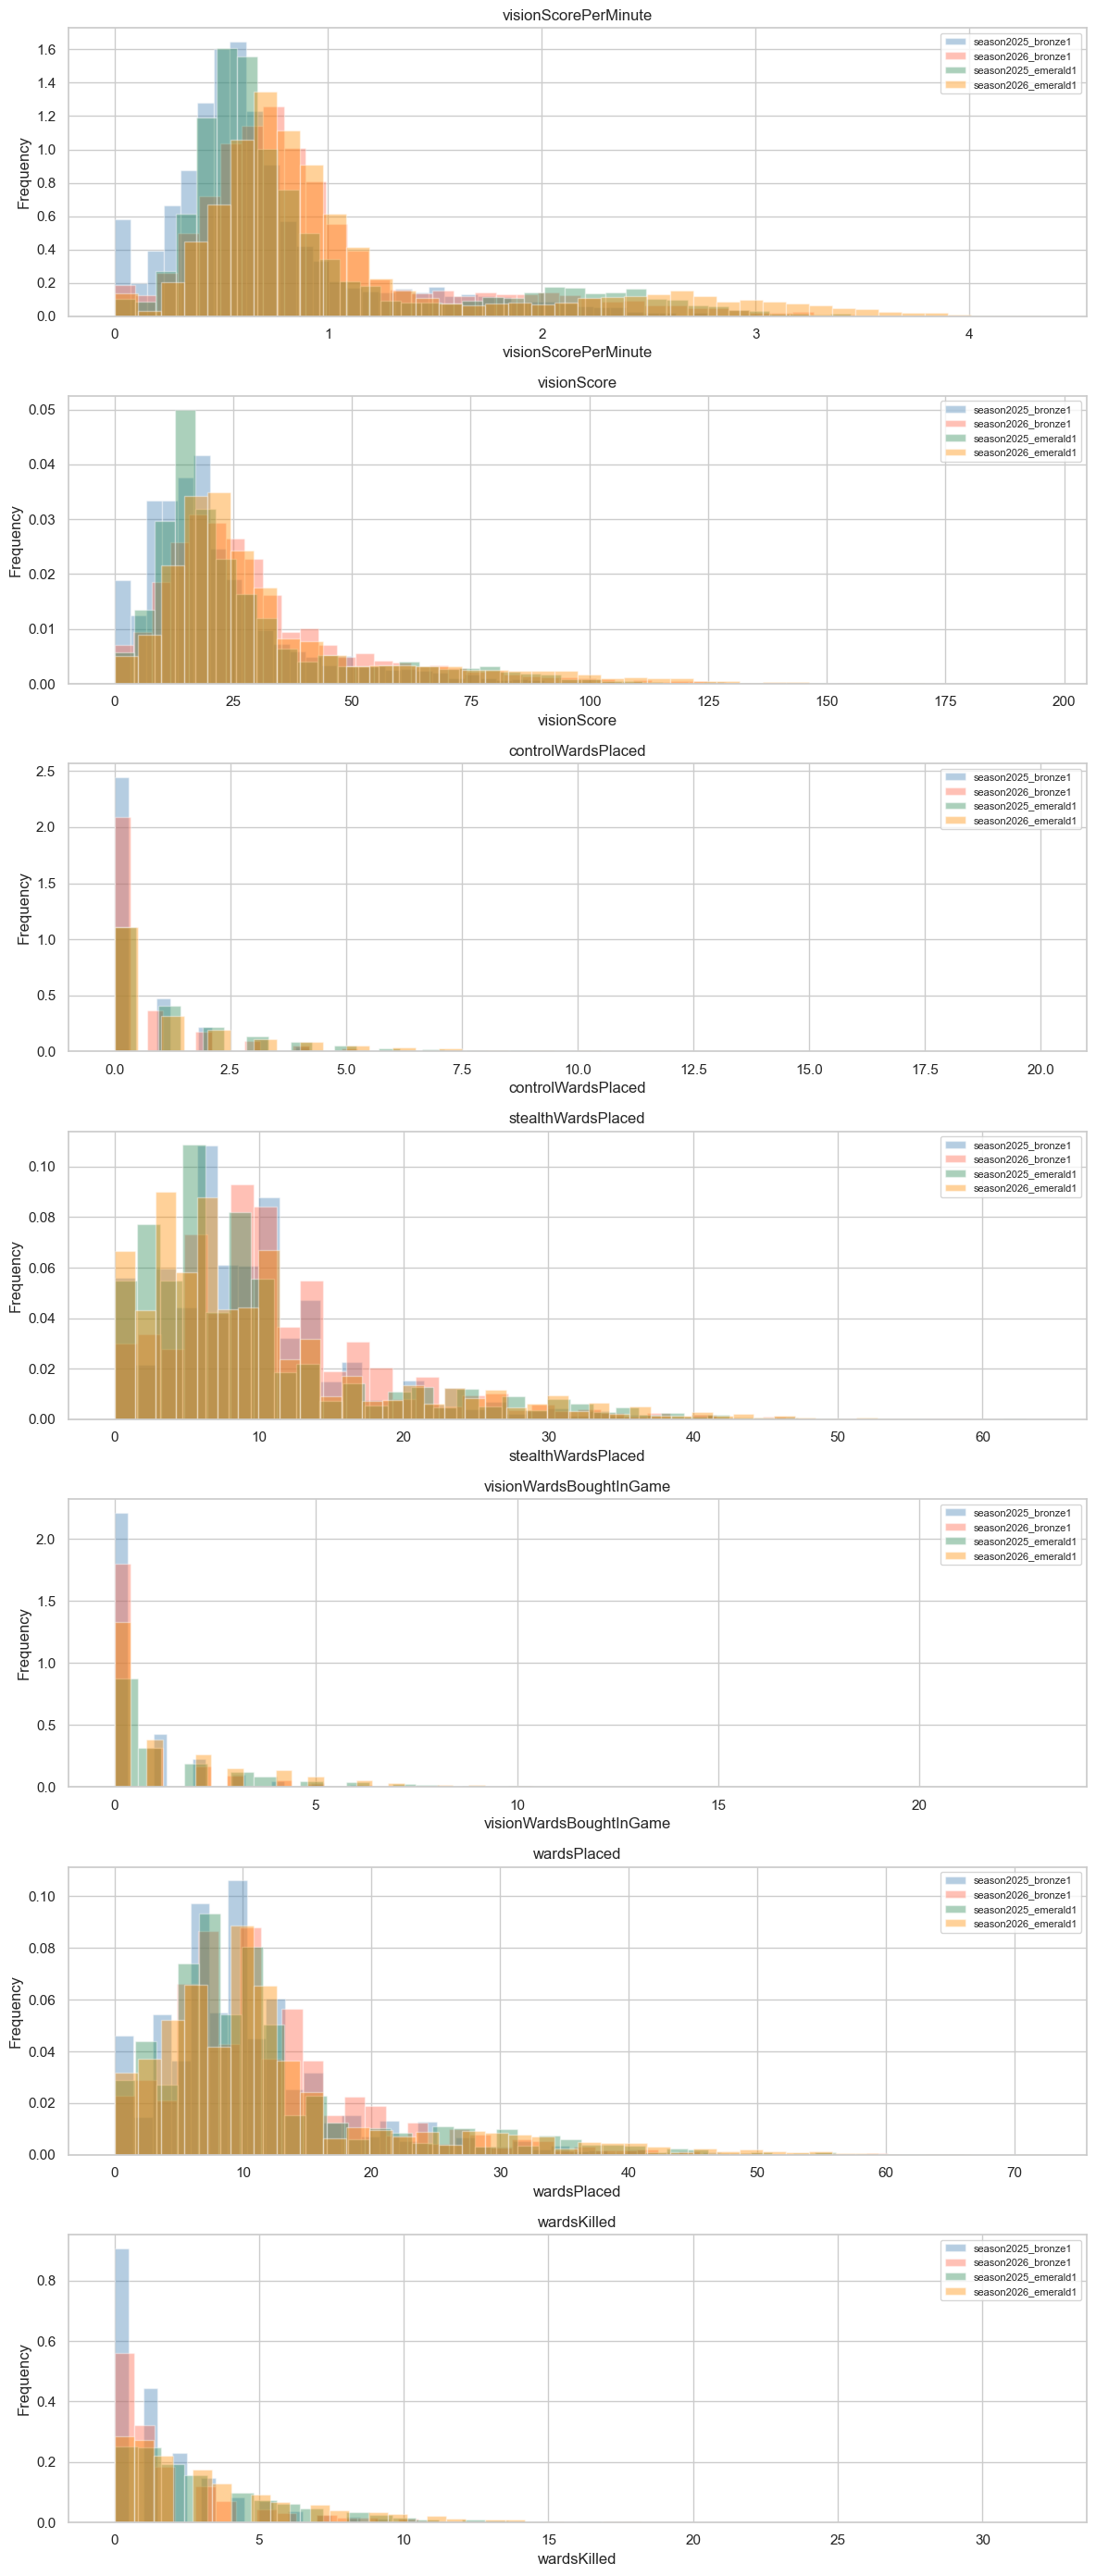

In [7]:
groups = ['season2025_bronze1', 'season2026_bronze1', 'season2025_emerald1', 'season2026_emerald1']
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']

fig, axes = plt.subplots(len(FEATURES), 1, figsize=(12, 4 * len(FEATURES)))
for ax, feat in zip(axes, FEATURES):
    for grp, col in zip(groups, colors):
        vals = df_all.loc[df_all['group'] == grp, feat].dropna()
        vals.plot.hist(ax=ax, alpha=0.4, bins=40, color=col, density=True, label=grp)
    ax.set_title(feat)
    ax.legend(fontsize=8)
    ax.set_xlabel(feat)
plt.tight_layout()
plt.savefig('figures/distributions.png', dpi=100)
plt.show()

## Boxplots

C:\Users\jezna\AppData\Local\Temp\ipykernel_18040\1359906980.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
C:\Users\jezna\AppData\Local\Temp\ipykernel_18040\1359906980.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
C:\Users\jezna\AppData\Local\Temp\ipykernel_18040\1359906980.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
C:\Users\jezna\AppData\Local\Temp\ipykernel_18040\1359906980.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or us

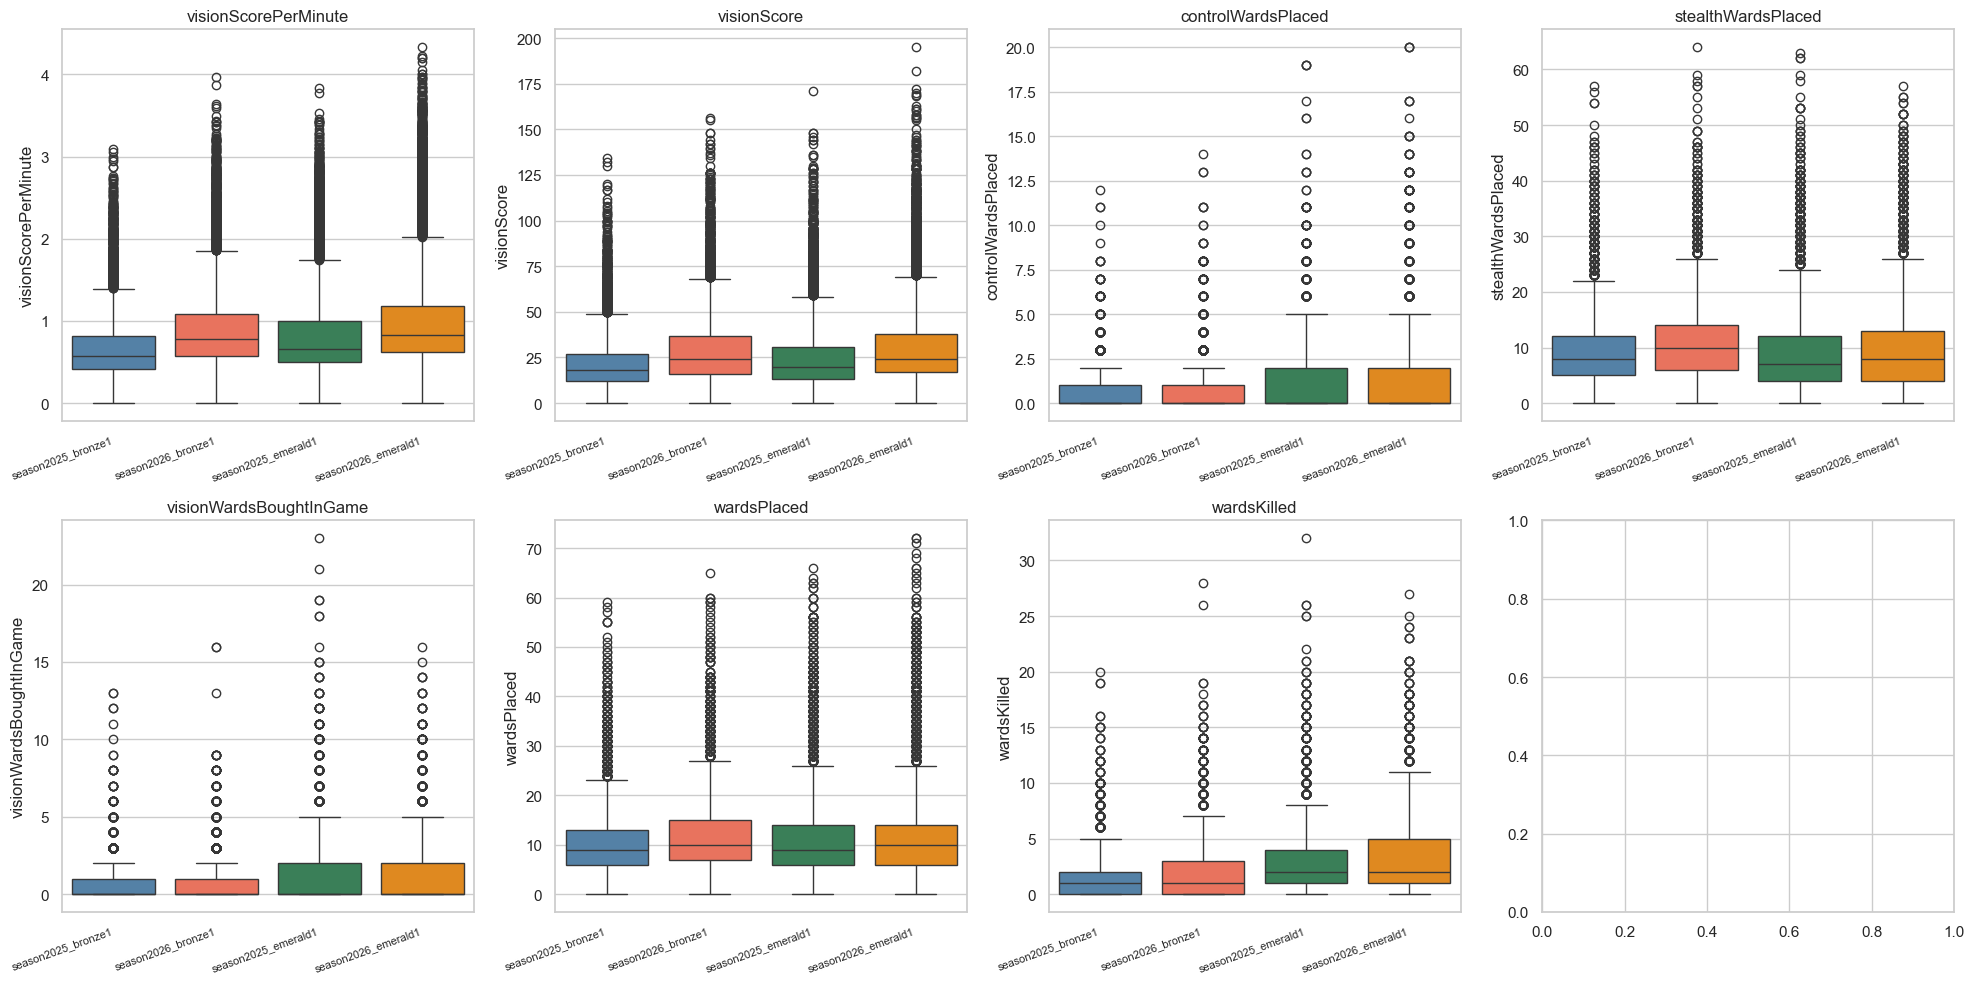

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, feat in zip(axes.flat, FEATURES):
    sns.boxplot(data=df_all, x='group', y=feat, ax=ax, hue='group', legend=False,
                order=groups, palette=colors)
    ax.set_title(feat)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
    ax.set_xlabel('')
plt.tight_layout()
plt.savefig('figures/boxplots.png', dpi=100)
plt.show()

## Normality tests

- **Shapiro-Wilk** (best for n < 5000, used when subsample ≤ 5000)
- **D'Agostino–Pearson** (`normaltest`) as a complement

α = 0.05; if both tests fail to reject H₀ (p > 0.05) → assume normal; otherwise → non-normal.

In [ ]:
ALPHA = 0.05
SHAPIRO_MAX = 5500   # shapiro is slow, go for random sample when population is too big

normality_results = []
for grp in groups:
    for feat in FEATURES:
        vals = df_all.loc[df_all['group'] == grp, feat].dropna().values
        n = len(vals)

        # Shapiro-Wilk on subsample if large
        sample = np.random.default_rng(42).choice(vals, size=min(n, SHAPIRO_MAX), replace=False)
        sw_stat, sw_p = shapiro(sample)

        # D'Agostino-Pearson (needs n >= 20)
        if n >= 20:
            dp_stat, dp_p = normaltest(vals)
        else:
            dp_stat, dp_p = np.nan, np.nan

        is_normal = (sw_p > ALPHA) and (dp_p > ALPHA if not np.isnan(dp_p) else True)

        normality_results.append({
            'group': grp, 'feature': feat, 'n': n,
            'shapiro_stat': round(sw_stat, 4), 'shapiro_p': round(sw_p, 6),
            'dagostino_stat': round(dp_stat, 4) if not np.isnan(dp_stat) else np.nan,
            'dagostino_p': round(dp_p, 6) if not np.isnan(dp_p) else np.nan,
            'normal': is_normal,
        })

norm_df = pd.DataFrame(normality_results)
norm_df

c:\Users\jezna\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5300.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\jezna\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5330.
  res = hypotest_fun_out(*samples, **kwds)


,group,feature,n,shapiro_stat,shapiro_p,dagostino_stat,dagostino_p,normal
0,season2025_bronze1,visionScorePerMinute,4230,0.8520,0.0,1236.3676,0.0,False
1,season2025_bronze1,visionScore,4230,0.8317,0.0,1642.4455,0.0,False
2,season2025_bronze1,controlWardsPlaced,4230,0.5267,0.0,3094.9546,0.0,False
3,season2025_bronze1,stealthWardsPlaced,4230,0.8640,0.0,1525.3329,0.0,False
4,season2025_bronze1,visionWardsBoughtInGame,4230,0.5331,0.0,3130.1421,0.0,False
5,season2025_bronze1,wardsPlaced,4230,0.8617,0.0,1534.7622,0.0,False
6,season2025_bronze1,wardsKilled,4230,0.6996,0.0,2290.1366,0.0,False
7,season2026_bronze1,visionScorePerMinute,5300,0.8573,0.0,1423.4761,0.0,False
8,season2026_bronze1,visionScore,5300,0.8504,0.0,1786.5741,0.0,False
9,season2026_bronze1,controlWardsPlaced,5300,0.5122,0.0,3873.9436,0.0,False


## Statistical comparison tests

Comparison pairs:
1. **Bronze I**: season2025 vs season2026
2. **Emerald I**: season2025 vs season2026

Decision rule:
- If **both** groups are normal → **Welch's t-test** (accounts for unequal variances via Levene's test)
- Otherwise → **Mann-Whitney U test** (non-parametric)

Effect size:
- t-test → **Cohen's d**
- Mann-Whitney → **rank-biserial correlation r**

In [ ]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na - 1) * np.var(a, ddof=1) + (nb - 1) * np.var(b, ddof=1)) / (na + nb - 2))
    return (np.mean(a) - np.mean(b)) / pooled_std if pooled_std > 0 else 0.0

def rank_biserial(u_stat, n1, n2):
    return 1 - (2 * u_stat) / (n1 * n2)


def is_normal_group(norm_df, grp, feat):
    row = norm_df[(norm_df['group'] == grp) & (norm_df['feature'] == feat)]
    if row.empty:
        return False
    return bool(row.iloc[0]['normal'])


comparison_pairs = [
    ('season2025_bronze1',  'season2026_bronze1',  'Bronze I'),
    ('season2025_emerald1', 'season2026_emerald1', 'Emerald I'),
]

test_results = []
for g1, g2, label in comparison_pairs:
    for feat in FEATURES:
        a = df_all.loc[df_all['group'] == g1, feat].dropna().values
        b = df_all.loc[df_all['group'] == g2, feat].dropna().values

        both_normal = is_normal_group(norm_df, g1, feat) and is_normal_group(norm_df, g2, feat)

        if both_normal:
            # Welch's t-test (equal_var=False)
            stat, p = ttest_ind(a, b, equal_var=False)
            test_name = "Welch's t-test"
            effect = cohens_d(a, b)
            effect_name = "Cohen's d"
        else:
            # Mann-Whitney U test
            result = mannwhitneyu(a, b, alternative='two-sided')
            stat, p = result.statistic, result.pvalue
            test_name = 'Mann-Whitney U'
            effect = rank_biserial(stat, len(a), len(b))
            effect_name = 'rank-biserial r'

        test_results.append({
            'comparison': label,
            'feature': feat,
            'test': test_name,
            'statistic': round(stat, 4),
            'p_value': round(p, 6),
            'significant (α=0.05)': p < ALPHA,
            effect_name: round(effect, 4),
            'mean_2025': round(np.mean(a), 4),
            'mean_2026': round(np.mean(b), 4),
            'median_2025': round(np.median(a), 4),
            'median_2026': round(np.median(b), 4),
        })

results_df = pd.DataFrame(test_results)
results_df

,comparison,feature,test,statistic,p_value,significant (α=0.05),rank-biserial r,mean_2025,mean_2026,median_2025,median_2026
0,Bronze I,visionScorePerMinute,Mann-Whitney U,7861759.0,0.000000,True,0.2987,0.7059,0.9431,0.5790,0.7802
1,Bronze I,visionScore,Mann-Whitney U,8295016.0,0.000000,True,0.2600,22.3038,30.3026,18.0000,24.0000
2,Bronze I,controlWardsPlaced,Mann-Whitney U,11115035.0,0.362763,False,0.0084,0.5047,0.5953,0.0000,0.0000
3,Bronze I,stealthWardsPlaced,Mann-Whitney U,9792067.0,0.000000,True,0.1264,9.9095,11.3217,8.0000,10.0000
4,Bronze I,visionWardsBoughtInGame,Mann-Whitney U,11153052.5,0.592840,False,0.0050,0.5752,0.6353,0.0000,0.0000
5,Bronze I,wardsPlaced,Mann-Whitney U,9831346.5,0.000000,True,0.1229,10.6811,12.1875,9.0000,10.0000
6,Bronze I,wardsKilled,Mann-Whitney U,10337642.5,0.000000,True,0.0778,1.4868,1.8557,1.0000,1.0000
7,Emerald I,visionScorePerMinute,Mann-Whitney U,10310790.0,0.000000,True,0.2262,0.9136,1.1118,0.6571,0.8248
8,Emerald I,visionScore,Mann-Whitney U,10966000.5,0.000000,True,0.1770,27.5244,33.2448,20.0000,24.0000
9,Emerald I,controlWardsPlaced,Mann-Whitney U,13454413.0,0.349592,False,-0.0097,1.2278,1.3508,0.0000,0.0000


## Summary — significant differences

In [14]:
sig = results_df[results_df['significant (α=0.05)']]
print(f'Significant results: {len(sig)} / {len(results_df)}')
sig[['comparison', 'feature', 'test', 'p_value', "Cohen's d", 'rank-biserial r', 'mean_2025', 'mean_2026']]

Significant results: 10 / 14


KeyError: '["Cohen\'s d"] not in index'